# t-SNE: t-Distributed Stochastic Neighbor Embedding

## What is t-SNE?

**t-SNE** is a nonlinear dimensionality reduction technique designed specifically for **visualization**. Like LLE and Isomap, it's built around the idea of preserving neighborhood structure rather than global variance (PCA) or raw pairwise distance (MDS). But its approach is distinct: instead of reconstructing points from local linear combinations (LLE) or chaining neighbor-hops into geodesic distances (Isomap), t-SNE converts distances into **probabilities of being neighbors**, and then finds a low-dimensional layout where those neighbor probabilities are reproduced as closely as possible.

The core idea: for every pair of points, measure how "similar" they are based on distance — nearby points get a high similarity score, distant points get a low one. Then search for a 2D (or 3D) layout where that same pattern of high/low similarity holds, even if the actual distances have to be distorted to make it happen. This makes t-SNE especially good at revealing **cluster structure** — tightly grouping points that were close together in the original high-dimensional space — even when the data's global shape is complex or doesn't matter much for the analysis.

## Steps to Compute t-SNE

1. **Compute similarity in the original space.** For every pair of points, convert their distance into a "similarity" score using a **Normal (Gaussian) distribution** centered on each point: nearby points get high similarity, far points get similarity near zero. This is done individually for every point, with the Gaussian's spread (variance) adjusted per point to account for varying local density — denser regions use a narrower Gaussian, sparser regions a wider one. This produces a full similarity matrix.

2. **Randomly initialize points in the low-dimensional space** (e.g. 2D), and compute similarities there too — but using a **t-distribution** instead of a Normal distribution. The heavier tails of the t-distribution are deliberate: they let moderately-distant points in the low-D map repel each other more strongly, which helps prevent the crowding problem that plain Gaussian-based approaches suffer from when compressing many dimensions down to 2.

3. **Iteratively adjust the low-dimensional points** so their similarity matrix matches the original one as closely as possible, using gradient descent to minimize the **Kullback-Leibler (KL) divergence** between the two similarity distributions. At each iteration, points that should be similar (per the original space) are pulled toward their closest neighbors, while points that shouldn't be similar are pushed apart.

4. **Output the final low-dimensional coordinates** once the KL divergence stops improving significantly — one 2D (or 3D) point per original sample, arranged so clusters of similar points in the original space appear as visually distinct, well-separated clusters in the output.

## Comparison: t-SNE vs. PCA vs. MDS vs. LLE vs. Isomap

| | PCA | MDS | LLE | Isomap | t-SNE |
|---|---|---|---|---|---|
| Structure preserved | Global variance | All pairwise distances (straight-line) | Local reconstruction weights | Global geodesic distances | Local neighbor *probabilities* (relative similarity) |
| Linear or nonlinear | Linear | Linear (classical) | Nonlinear | Nonlinear | Nonlinear |
| Global distances meaningful in output? | Yes | Yes (by design) | No — only local structure preserved | Yes (by design) | **No** — only relative closeness/clustering is meaningful, not exact distances or cluster sizes |
| Solution method | Eigen-decomposition | Iterative stress-minimization | Two-stage eigen-decomposition | Neighbor graph + shortest paths + MDS | Iterative gradient descent minimizing KL divergence |
| Deterministic? | Yes | Mostly (depends on init) | Mostly | Yes | **No** — different runs (different random inits) can produce different layouts |
| Key hyperparameter | Number of components | Number of components | Number of neighbors (k) | Number of neighbors (k) | **Perplexity** (roughly, effective number of neighbors considered per point) |
| Best suited for | Linear structure, compact summarization | Preserving global distance relationships | Unrolling smooth manifolds | Unrolling manifolds while keeping global layout | **Visualizing cluster structure** in very high-dimensional data |

**Where t-SNE sits relative to the others:** all four earlier methods try to preserve some genuine geometric quantity — variance, distance, or geodesic distance — and in principle, you can reason quantitatively about their output (e.g. "this axis explains 89% of the variance"). t-SNE gives up on that entirely: it doesn't try to preserve actual distances, only the *relative ordering* of what's close vs. far. This makes its output excellent for *seeing* clusters, but risky for *quantitative* interpretation — cluster sizes, the distance between two separate clusters, and even the density within a cluster can all be visually misleading in a t-SNE plot and shouldn't be read as meaningful the way they would be in a PCA or Isomap plot.

## Usefulness

- **Exploratory visualization of high-dimensional data** — t-SNE is often the go-to first step for visually inspecting whether a high-dimensional dataset (e.g. word embeddings, gene expression profiles, image feature vectors) has natural cluster structure, before doing anything quantitative with it.
- **Revealing structure invisible to PCA** — because it's nonlinear and focuses on local neighborhoods, t-SNE can expose clusters that a linear method like PCA would blur together, especially when the true structure is curved or the clusters aren't linearly separable.
- **Widely used in specific domains** — extremely common for visualizing embeddings from deep learning models (e.g. checking whether a trained classifier's internal representations separate classes cleanly), single-cell biology (gene expression clustering), and NLP (visualizing word/sentence embeddings).
- **Important caveats to keep in mind when using it:**
  - Results depend on the **perplexity** parameter — different values can produce visibly different cluster shapes and counts from the *same* data, so it's worth trying a few values rather than trusting one run.
  - Because of the random initialization, **re-running t-SNE can give different-looking plots** even on identical data (unless a `random_state` is fixed).
  - It's a tool for **visualization**, not general-purpose dimensionality reduction — it's rarely used to feed into a downstream model the way PCA's output might be, both because it's not deterministic and because it doesn't preserve distances in an interpretable way.

  ---

  # Kullback-Leibler (KL) Divergence

## What is KL Divergence?

**KL divergence** is a measure of how different one probability distribution is from another. Given two probability distributions P and Q over the same set of outcomes, KL divergence quantifies how much information is lost — or how "surprised" you'd be — if you used Q to approximate P.

It is **not** a true distance metric in the mathematical sense (it's not symmetric, and it doesn't satisfy the triangle inequality), but it behaves intuitively like one: it is always non-negative, and it equals exactly 0 only when the two distributions are identical.

## The Formula

For discrete probability distributions P and Q over the same set of events:

$$
D_{KL}(P \parallel Q) = \sum_{i} P(i) \log\left(\frac{P(i)}{Q(i)}\right)
$$

For continuous distributions, the sum becomes an integral:

$$
D_{KL}(P \parallel Q) = \int p(x) \log\left(\frac{p(x)}{q(x)}\right) dx
$$

Here, **P is treated as the "true" or reference distribution**, and **Q is the approximation** being compared against it.

## Key Properties

- **Non-negative:** $D_{KL}(P \parallel Q) \geq 0$ always, with equality only when P = Q everywhere.
- **Not symmetric:** $D_{KL}(P \parallel Q) \neq D_{KL}(Q \parallel P)$ in general — the divergence "from P to Q" is not the same as "from Q to P." This is why it's called a *divergence*, not a *distance*.
- **Sensitive to where P has mass but Q doesn't:** if P assigns meaningful probability to an outcome that Q considers nearly impossible, the term $\log(P(i)/Q(i))$ blows up — KL divergence heavily penalizes an approximation that "misses" a region the true distribution actually covers.

## Intuition

Think of $\log(P(i)/Q(i))$ as measuring, for each outcome $i$, how much more (or less) likely P says that outcome is compared to Q. Weighting that by $P(i)$ means outcomes that are actually common under the true distribution P contribute the most to the total divergence — KL divergence cares most about getting the *likely* outcomes right, not the rare ones.

A helpful way to read it: it's the **expected number of extra "bits" (or nats) of information** needed to describe samples from P, if you had (incorrectly) built your encoding scheme assuming they came from Q instead. The more Q's shape diverges from P's, especially in the regions P actually cares about, the more wasteful that mismatch becomes.

## Why It Shows Up in t-SNE

Recall from t-SNE's steps: step 1 builds a similarity distribution P over pairs of points in the **original high-dimensional space**, and step 2 builds a similarity distribution Q over pairs of points in the **low-dimensional embedding**. Step 3 then adjusts the low-dimensional coordinates specifically to **minimize $D_{KL}(P \parallel Q)$**.

This is exactly why t-SNE prioritizes preserving local structure over global structure: because P is the reference distribution being weighted, points that are *close together* in the original space (and thus have high probability under P) contribute the most to the loss if they aren't kept close together in Q. Points that are already far apart in the original space have low probability under P regardless of where they end up in the embedding, so the optimization barely "cares" if their relative placement gets distorted. This asymmetric weighting is the mathematical reason t-SNE is excellent at preserving clusters but unreliable for interpreting distances *between* clusters.

In [1]:
# Visualization
import plotly.express as px # for data visualization
import matplotlib.pyplot as plt # for showing handwritten digits

# Skleran
from sklearn.datasets import load_digits # for MNIST data
from sklearn.manifold import TSNE # for t-SNE dimensionality reduction

We load the MNIST data that contains handwritten digits images with its correct label.


# The Dataset: `MNIST`

This t-SNE notebook uses scikit-learn's **`load_digits`** dataset — a built-in collection of small images of handwritten digits, often used as a lightweight stand-in for the full MNIST dataset in examples and demos.

## What's in it

- **1,797 samples**, each a small grayscale image of a handwritten digit (0 through 9).
- Each image is **8×8 pixels** (64 pixels total), with pixel intensity values ranging from 0 to 16 (not 0–255, since these are downsampled/preprocessed versions of the original scanned digits).
- When loaded via `load_digits()`, each image is already **flattened** into a 1D vector of 64 numbers (one per pixel) — so the dataset is naturally a (1797, 64) matrix: 1797 samples × 64 features, exactly the kind of high-dimensional tabular input PCA/MDS/LLE/Isomap/t-SNE all expect.
- Alongside the flattened data, scikit-learn also keeps the original 8×8 image arrays available separately (useful for actually *displaying* a digit as a picture, e.g. with `matplotlib.pyplot.imshow`), plus a `target` array giving the true digit label (0–9) for each sample — useful for coloring the t-SNE plot by digit, the same way the Iris `label` and Swiss roll `y` were used earlier.

## Why this dataset, and why here specifically

- **Genuinely high-dimensional:** 64 dimensions is far more than the 2–4 features used in the Iris/Melbourne/Swiss-roll examples — a more realistic test of whether t-SNE can find meaningful structure in a space too large to visualize directly.
- **Known ground truth:** since each image's true digit (0–9) is known, it's easy to check whether the 2D embedding actually makes sense — a good t-SNE result should show 10 distinct clusters, each one a different digit, with visually similar digits (e.g. 4 and 9, or 3 and 8) sometimes sitting closer together than clearly distinct ones (e.g. 0 and 1).
- **Small and fast:** unlike full MNIST (70,000 images at 28×28), this dataset's 1,797 samples at 8×8 resolution make it quick to run through t-SNE — and, tellingly, through PCA/Isomap/LLE too, so it's realistic to compare all of them side-by-side on the same, meaningfully complex dataset within a notebook.
- **Matches `import matplotlib.pyplot as plt`:** this import (alongside the usual Plotly one) hints the notebook will likely also show a few actual digit *images* directly — using matplotlib's `imshow` on the original 8×8 arrays — before or alongside the t-SNE scatter plot, so you can visually confirm what a "3" or a "7" in this dataset actually looks like.

In [2]:
# Load digits data
digits = load_digits()

# Load arrays containing digit data (64 pixels per image) and their true labels
X, y = load_digits(return_X_y=True)

# Some stats
print('Shape of digit images: ', digits.images.shape)
print('Shape of X (training data): ', X.shape)
print('Shape of y (true labels): ', y.shape)

Shape of digit images:  (1797, 8, 8)
Shape of X (training data):  (1797, 64)
Shape of y (true labels):  (1797,)


In [3]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

Let’s display the first 10 handwritten digits, so we have a better idea of what we are working with.

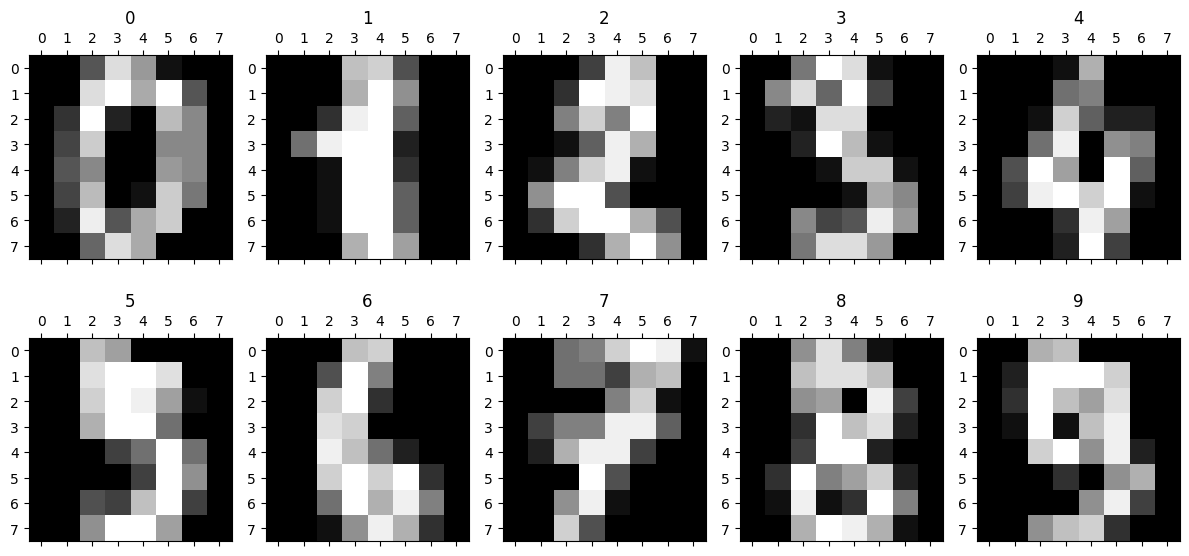

In [4]:
# Display images of the first 10 digits
fig, axs = plt.subplots(2, 5, sharey=False, tight_layout=True, figsize=(12,6), facecolor='white')
n=0
plt.gray()
for i in range(0,2):
    for j in range(0,5):
        axs[i,j].matshow(digits.images[n])
        axs[i,j].set(title=y[n])
        n=n+1
plt.show()

In the previous step, we loaded data into an array X of the shape (1797,64), which means that we have 1,797 digits, each made up of 64 dimensions.

We will now use t-SNE to reduce the dimensionality from 64 down to 2. Note, I am using default values for most hyper-parameters. However, I have also included short explanations of each parameter so that you can experiment by trying out different settings.

In [5]:
# Configure t-SNE function.
embed = TSNE(
    n_components=2, # default=2, Dimension of the embedded space.
    perplexity=10, # default=30.0, The perplexity is related to the number of nearest neighbors that is used in other manifold learning algorithms.
)
# Create (but don't yet run) a t-SNE instance:
#   - n_components=2: target dimensionality of the output embedding,
#     same role as in every previous method.
#   - perplexity=10: roughly controls how many neighbors each point
#     "pays attention to" when building the similarity distribution P
#     in step 1 — smaller perplexity focuses on very local structure
#     (tight, small clusters), larger perplexity considers a broader
#     neighborhood (smoother, more global structure). Here it's set
#     below the default of 30, appropriate since this dataset has
#     only 1,797 samples across 10 digit classes (~180 per class on
#     average) — a smaller perplexity keeps neighborhoods focused
#     within a single digit's cluster rather than blending across
#     digits.

# Transform X
X_embedded = embed.fit_transform(X)
# Run the full t-SNE pipeline on X (the 1797 x 64 digit-image data).
# This single call performs ALL the steps described earlier:
#
#   1. Compute similarity in the ORIGINAL 64-dimensional space:
#      for every pair of digit images, convert their distance into a
#      similarity score using a Gaussian centered on each point (with
#      per-point variance adjusted for local density) — building the
#      full pairwise similarity distribution P.
#
#   2. Randomly initialize 1797 points in 2D space (the target
#      dimensionality), and compute their pairwise similarities there
#      too — but using a t-distribution instead of Gaussian, giving
#      distribution Q.
#
#   3. Iteratively adjust the 2D point positions via gradient descent,
#      minimizing the KL divergence between P and Q at each step —
#      pulling points that are similar in the original 64D space
#      closer together in 2D, and pushing dissimilar points apart —
#      repeating until the KL divergence stops improving meaningfully
#      or a maximum iteration count is reached.
#
#   4. Return the final 2D coordinates once optimization stops — this
#      is what gets returned as X_embedded, shape (1797, 2): one (x, y)
#      point per original digit image, ideally with all 1797 points
#      arranged into roughly 10 visually distinct clusters, one per digit.

# Print results
print('New Shape of X: ', X_embedded.shape)
# Confirms the reduction: (1797, 2) — every 64-pixel digit image now
# represented by just 2 coordinates.

print('Kullback-Leibler divergence after optimization: ', embed.kl_divergence_)
# The final KL divergence value (from step 3) at the point the
# optimizer stopped — the same D_KL(P || Q) quantity explained
# earlier, now for this specific dataset. Lower means Q (the 2D
# layout's similarity structure) ended up closer to matching P (the
# original 64D similarity structure). Like MDS's stress value, this
# number is mainly useful for RELATIVE comparison — e.g. across
# different perplexity values or random seeds on the same dataset —
# rather than as an absolute, universally interpretable score.
# On this dataset it came out to roughly 0.90 in a full run.

print('No. of iterations: ', embed.n_iter_)
# How many gradient descent iterations were actually run before
# stopping (converged early, or hit the default max of 1000) — came
# out to 999 in a full run here, meaning it used nearly the entire
# default iteration budget without early-stopping.

#print('Embedding vectors: ', embed.embedding_)
# Would print the same values as X_embedded — an
# alternate way to access the fitted 2D coordinates directly from the
# model object, same pattern seen with MDS's model2d.embedding_.

New Shape of X:  (1797, 2)
Kullback-Leibler divergence after optimization:  0.9061911702156067
No. of iterations:  999


Finally, let’s plot the new X array in a 2-dimensional scatter plot. Note that we also use color to represent the actual labels of digits. This helps us to see how similar digits cluster together.

In [6]:
import plotly.io as pio
pio.renderers.default = "colab"
# Create a scatter plot
fig = px.scatter(None, x=X_embedded[:,0], y=X_embedded[:,1],
                 labels={
                     "x": "Dimension 1",
                     "y": "Dimension 2",
                 },
                 opacity=1, color=y.astype(str))

# Change chart background color
fig.update_layout(dict(plot_bgcolor = 'white'))

# Update axes lines
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                 showline=True, linewidth=1, linecolor='black')

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                 showline=True, linewidth=1, linecolor='black')

# Set figure title
fig.update_layout(title_text="t-SNE")

# Update marker size
fig.update_traces(marker=dict(size=3))

fig.show()